# Differentiable KS-DFT in 3D
### Compute the dataset and components to launch the training

In [7]:
import qex
from qex.legacy.td.data_io.dataset_generation import DataGenerator, MoleculeConfig
from pathlib import Path
import os
from loguru import logger

# Example usage
config = MoleculeConfig(
    name="H2_test",
    atom_coords="H 0 0 0; H 0 0 0.74",
    units="Ang",
    basis="631g",
    method="CCSD",
    grid_density=0,
)

project_path = Path(os.path.dirname(os.path.dirname(qex.__file__)))
output_dir = project_path / "data" / "td"
generator = DataGenerator(output_dir=output_dir)
mol, mf, dm_ao, energy, density, coords = generator.generate_data(config, save_data=True)

2026-05-13 16:42:32.518 | INFO     | qex.data_io.td.dataset_generation:calculate_energy_and_density:321 -     Generating data using ccsd method


converged SCF energy = -1.12675531719693
E(CCSD) = -1.151672678339737  E_corr = -0.02491736114280623
E(CCSD) = -1.151672678339737  E_corr = -0.02491736114280623
converged SCF energy = -1.03718794786902


2026-05-13 16:42:33.035 | INFO     | qex.data_io.td.dataset_generation:calculate_energy_and_density:510 -     Number of grid points: 1240
2026-05-13 16:42:33.035 | INFO     | qex.data_io.td.dataset_generation:calculate_energy_and_density:511 -     Density matrix AO shape: (4, 4)
2026-05-13 16:42:33.035 | INFO     | qex.data_io.td.dataset_generation:calculate_energy_and_density:512 -     Shape of rho: (1240,)
2026-05-13 16:42:33.036 | INFO     | qex.data_io.td.dataset_generation:calculate_energy_and_density:513 -     Energy total: -1.1516726783397373
2026-05-13 16:42:33.057 | INFO     | qex.data_io.td.dataset_generation:parse_density_data:204 - 
PARSER: Starting and converting if needed to Ang...
2026-05-13 16:42:33.057 | INFO     | qex.data_io.td.dataset_generation:parse_density_data:205 - PARSER: PySCF typically does everything in NOT in Angstroms (A) but Bohr (B) - atomic units.
2026-05-13 16:42:33.057 | INFO     | qex.data_io.td.dataset_generation:parse_density_data:213 - PARSER: Al

In [8]:
print(f"Generated data for {config.name}")
print(f"Energy: {energy}")
print(f"Grid points: {coords.shape[0]}")
print(f"Density: {density}")
print(f"Density shape: {density.shape}")
print(f"DM AO shape: {dm_ao.shape}")
print(f"DM AO: {dm_ao}")
print(f"Molecule: {mol}")
print(f"Mean field: {mf}")

Generated data for H2_test
Energy: -1.1516726783397373
Grid points: 1240
Density: [6.19300135e-09 6.19300135e-09 3.52487575e-09 ... 3.52487575e-09
 6.19300135e-09 6.19300135e-09]
Density shape: (1240,)
DM AO shape: (4, 4)
DM AO: [[0.23211218 0.18285689 0.20607785 0.16169728]
 [0.18285689 0.1546802  0.16169728 0.133479  ]
 [0.20607785 0.16169728 0.23211218 0.18285689]
 [0.16169728 0.133479   0.18285689 0.1546802 ]]
Molecule: <pyscfad.gto.mole.Mole object at 0x14ab12a10>
Mean field: <pyscfad.dft.rks.RKS object at 0x1651e97d0>


# Launch the training 

In [9]:
# Get project path
project_path = Path(os.path.dirname(os.path.dirname(qex.__file__)))

import jax.numpy as jnp

# Create H2 bonds example
h2_config = {
    "features": [512, 512, 1],
    "train_bond_lengths": [0.74, 0.5, 0.6, 0.7, 0.9, 1.0, 1.5, 2.0, 2.5],
    "val_bond_lengths": [0.6, 0.9, 1.2],
    "n_iterations": 1000,  # Small for testing
    "batch_size": 3,
    "is_global_xc": True,
    "results_dir": "results/h2_test_run",
}

# Create custom molecule example
custom_basis = "631g"
custom_method = "CCSD"

# Configuration with custom molecules
custom_config = None

# Choose which example to run
use_custom_molecules = False
config = custom_config if use_custom_molecules else h2_config

# Initialize network with STAX
from qex.legacy.models.networks import GlobalMLP
from qex.legacy.td.train.stax_to_flax_network import adapt_stax_for_training

model = GlobalMLP()
num_grid_points = 1240 # 1192
network_stax = model.build_network(grids=jnp.linspace(0, 1, num_grid_points))
stax_init_fn, stax_apply_fn = network_stax  # your STAX model
network, params = adapt_stax_for_training(stax_init_fn, stax_apply_fn, (num_grid_points,))
logger.info(f"Network initialized with {num_grid_points} grid points")

2026-05-13 16:42:46.780 | INFO     | __main__:<module>:37 - Network initialized with 1240 grid points


In [10]:
from qex.legacy.td.train.trainer_legacy_no_jit import TDKSDFTTrainer

# Initialize and train
trainer = TDKSDFTTrainer(config, network=network)
params, opt_state, train_losses, val_losses, val_iters = trainer.train()

print("Training and evaluation complete!")
print(f"Results saved in {trainer.results_dir}")

2026-05-13 16:42:49.202 | INFO     | qex.train.td.trainer_legacy_no_jit:__init__:168 - Initialized trainer with config: {'features': [512, 512, 1], 'train_bond_lengths': [0.74, 0.5, 0.6, 0.7, 0.9, 1.0, 1.5, 2.0, 2.5], 'val_bond_lengths': [0.6, 0.9, 1.2], 'n_iterations': 1000, 'batch_size': 3, 'is_global_xc': True, 'results_dir': 'results/h2_test_run'}
2026-05-13 16:42:49.204 | INFO     | qex.train.td.trainer_legacy_no_jit:prepare_dataset:215 - Generating training data...
2026-05-13 16:42:49.215 | INFO     | qex.data_io.td.dataset_generation:calculate_energy_and_density:321 -     Generating data using ccsd method


converged SCF energy = -1.12675531719693
E(CCSD) = -1.151672678339737  E_corr = -0.02491736114280623
E(CCSD) = -1.151672678339737  E_corr = -0.02491736114280623
converged SCF energy = -1.03718794786902


2026-05-13 16:42:49.372 | INFO     | qex.data_io.td.dataset_generation:calculate_energy_and_density:510 -     Number of grid points: 1240
2026-05-13 16:42:49.372 | INFO     | qex.data_io.td.dataset_generation:calculate_energy_and_density:511 -     Density matrix AO shape: (4, 4)
2026-05-13 16:42:49.372 | INFO     | qex.data_io.td.dataset_generation:calculate_energy_and_density:512 -     Shape of rho: (1240,)
2026-05-13 16:42:49.373 | INFO     | qex.data_io.td.dataset_generation:calculate_energy_and_density:513 -     Energy total: -1.1516726783397373
2026-05-13 16:42:49.382 | INFO     | qex.data_io.td.dataset_generation:parse_density_data:204 - 
PARSER: Starting and converting if needed to Ang...
2026-05-13 16:42:49.383 | INFO     | qex.data_io.td.dataset_generation:parse_density_data:205 - PARSER: PySCF typically does everything in NOT in Angstroms (A) but Bohr (B) - atomic units.
2026-05-13 16:42:49.383 | INFO     | qex.data_io.td.dataset_generation:parse_density_data:213 - PARSER: Al

converged SCF energy = -1.05802481296927
E(CCSD) = -1.077863888625149  E_corr = -0.01983907565588309
E(CCSD) = -1.077863888625149  E_corr = -0.01983907565588309
converged SCF energy = -0.953380491095777


2026-05-13 16:42:49.486 | INFO     | qex.data_io.td.dataset_generation:calculate_energy_and_density:510 -     Number of grid points: 1240
2026-05-13 16:42:49.486 | INFO     | qex.data_io.td.dataset_generation:calculate_energy_and_density:511 -     Density matrix AO shape: (4, 4)
2026-05-13 16:42:49.486 | INFO     | qex.data_io.td.dataset_generation:calculate_energy_and_density:512 -     Shape of rho: (1240,)
2026-05-13 16:42:49.486 | INFO     | qex.data_io.td.dataset_generation:calculate_energy_and_density:513 -     Energy total: -1.0778638886251495
2026-05-13 16:42:49.495 | INFO     | qex.data_io.td.dataset_generation:parse_density_data:204 - 
PARSER: Starting and converting if needed to Ang...
2026-05-13 16:42:49.495 | INFO     | qex.data_io.td.dataset_generation:parse_density_data:205 - PARSER: PySCF typically does everything in NOT in Angstroms (A) but Bohr (B) - atomic units.
2026-05-13 16:42:49.495 | INFO     | qex.data_io.td.dataset_generation:parse_density_data:213 - PARSER: Al

...

converged SCF energy = -1.11168637398406
E(CCSD) = -1.140602464558199  E_corr = -0.02891609057413499
E(CCSD) = -1.140602464558199  E_corr = -0.02891609057413499
converged SCF energy = -1.03435513689523


2026-05-13 16:42:50.803 | INFO     | qex.data_io.td.dataset_generation:calculate_energy_and_density:510 -     Number of grid points: 1240
2026-05-13 16:42:50.804 | INFO     | qex.data_io.td.dataset_generation:calculate_energy_and_density:511 -     Density matrix AO shape: (4, 4)
2026-05-13 16:42:50.804 | INFO     | qex.data_io.td.dataset_generation:calculate_energy_and_density:512 -     Shape of rho: (1240,)
2026-05-13 16:42:50.804 | INFO     | qex.data_io.td.dataset_generation:calculate_energy_and_density:513 -     Energy total: -1.1406024645581994
2026-05-13 16:42:50.810 | INFO     | qex.data_io.td.dataset_generation:calculate_energy_and_density:321 -     Generating data using ccsd method


converged SCF energy = -1.05575928255497
E(CCSD) = -1.095595490681589  E_corr = -0.03983620812662021
E(CCSD) = -1.095595490681589  E_corr = -0.03983620812662021
converged SCF energy = -0.992121453499656


2026-05-13 16:42:50.925 | INFO     | qex.data_io.td.dataset_generation:calculate_energy_and_density:510 -     Number of grid points: 1240
2026-05-13 16:42:50.926 | INFO     | qex.data_io.td.dataset_generation:calculate_energy_and_density:511 -     Density matrix AO shape: (4, 4)
2026-05-13 16:42:50.926 | INFO     | qex.data_io.td.dataset_generation:calculate_energy_and_density:512 -     Shape of rho: (1240,)
2026-05-13 16:42:50.926 | INFO     | qex.data_io.td.dataset_generation:calculate_energy_and_density:513 -     Energy total: -1.0955954906815886
2026-05-13 16:42:50.930 | INFO     | qex.train.td.trainer_legacy_no_jit:train:415 - Network initialized with 1240 grid points
2026-05-13 16:42:50.943 | INFO     | qex.train.td.trainer_legacy_no_jit:train:452 - Starting training...
  0%|          | 0/1000 [00:00<?, ?it/s]2026-05-13 16:42:54.643 | INFO     | qex.train.td.trainer_legacy_no_jit:train:485 - Iteration 0, Training Loss: 0.407082
2026-05-13 16:42:55.403 | INFO     | qex.train.td.tr

Training and evaluation complete!
Results saved in results/h2_test_run


In [11]:
# params, opt_state, train_losses, val_losses, val_iters
print(f"Training completed with final loss: {train_losses[-1]}")
print(f"Optimization info: {val_losses[-1]}")
print(f"Params: {params}")

Training completed with final loss: 0.13115899575524817
Optimization info: 0.07697873678716903
Params: {'params': {'stax_params': [(Array([[-0.0092708 , -0.04848896,  0.02078498, ..., -0.01591092,
        -0.02132313, -0.06596653],
       [ 0.08112031, -0.02420318,  0.00779807, ..., -0.00993428,
        -0.02779615, -0.05024354],
       [-0.00913763,  0.02865405, -0.02111498, ..., -0.02847225,
        -0.01391212,  0.05006268],
       ...,
       [-0.03930865, -0.01367681,  0.00263549, ..., -0.05695688,
         0.00507841, -0.03328703],
       [ 0.01555172,  0.06828193, -0.03653313, ..., -0.0066251 ,
        -0.00986001, -0.01990862],
       [-0.03625877,  0.01441469, -0.02705293, ...,  0.07420365,
         0.01835611,  0.01774459]], dtype=float64), Array([ 0.00531211, -0.00514839,  0.00476463, -0.01086185, -0.0004982 ,
        0.0157848 , -0.00596691, -0.01385391,  0.01228424, -0.0034084 ,
        0.00273637, -0.01358944,  0.00708559,  0.00084407, -0.01144307,
        0.01068439, -0.

# Dissociation profile
Evaluate the trained model across a range of H2 bond lengths and plot the H2 dissociation curve against the CCSD reference (and optionally LDA).

2026-05-13 19:58:32.742 | INFO     | qex.train.td.trainer_legacy_no_jit:evaluate:549 - Generating evaluation data...
2026-05-13 19:58:32.757 | INFO     | qex.data_io.td.dataset_generation:calculate_energy_and_density:321 -     Generating data using ccsd method


converged SCF energy = -0.93300420061077
E(CCSD) = -0.9506786531993083  E_corr = -0.01767445258853858
E(CCSD) = -0.9506786531993083  E_corr = -0.01767445258853858
converged SCF energy = -0.817546157645649


2026-05-13 19:58:32.957 | INFO     | qex.data_io.td.dataset_generation:calculate_energy_and_density:510 -     Number of grid points: 1240
2026-05-13 19:58:32.958 | INFO     | qex.data_io.td.dataset_generation:calculate_energy_and_density:511 -     Density matrix AO shape: (4, 4)
2026-05-13 19:58:32.959 | INFO     | qex.data_io.td.dataset_generation:calculate_energy_and_density:512 -     Shape of rho: (1240,)
2026-05-13 19:58:32.959 | INFO     | qex.data_io.td.dataset_generation:calculate_energy_and_density:513 -     Energy total: -0.9506786531993083
2026-05-13 19:58:32.969 | INFO     | qex.data_io.td.dataset_generation:calculate_energy_and_density:321 -     Generating data using ccsd method


converged SCF energy = -1.05802481296927
E(CCSD) = -1.077863888625149  E_corr = -0.01983907565588309
E(CCSD) = -1.077863888625149  E_corr = -0.01983907565588309
converged SCF energy = -0.953380491095777


2026-05-13 19:58:33.119 | INFO     | qex.data_io.td.dataset_generation:calculate_energy_and_density:510 -     Number of grid points: 1240
2026-05-13 19:58:33.120 | INFO     | qex.data_io.td.dataset_generation:calculate_energy_and_density:511 -     Density matrix AO shape: (4, 4)
2026-05-13 19:58:33.120 | INFO     | qex.data_io.td.dataset_generation:calculate_energy_and_density:512 -     Shape of rho: (1240,)
2026-05-13 19:58:33.120 | INFO     | qex.data_io.td.dataset_generation:calculate_energy_and_density:513 -     Energy total: -1.0778638886251495
2026-05-13 19:58:33.123 | INFO     | qex.data_io.td.dataset_generation:calculate_energy_and_density:321 -     Generating data using ccsd method


...

 83%|████████▎ | 10/12 [00:03<00:00,  2.63it/s]

converged SCF energy = -0.888625874767731


 92%|█████████▏| 11/12 [00:04<00:00,  2.57it/s]

converged SCF energy = -0.850286618565919


100%|██████████| 12/12 [00:04<00:00,  2.53it/s]


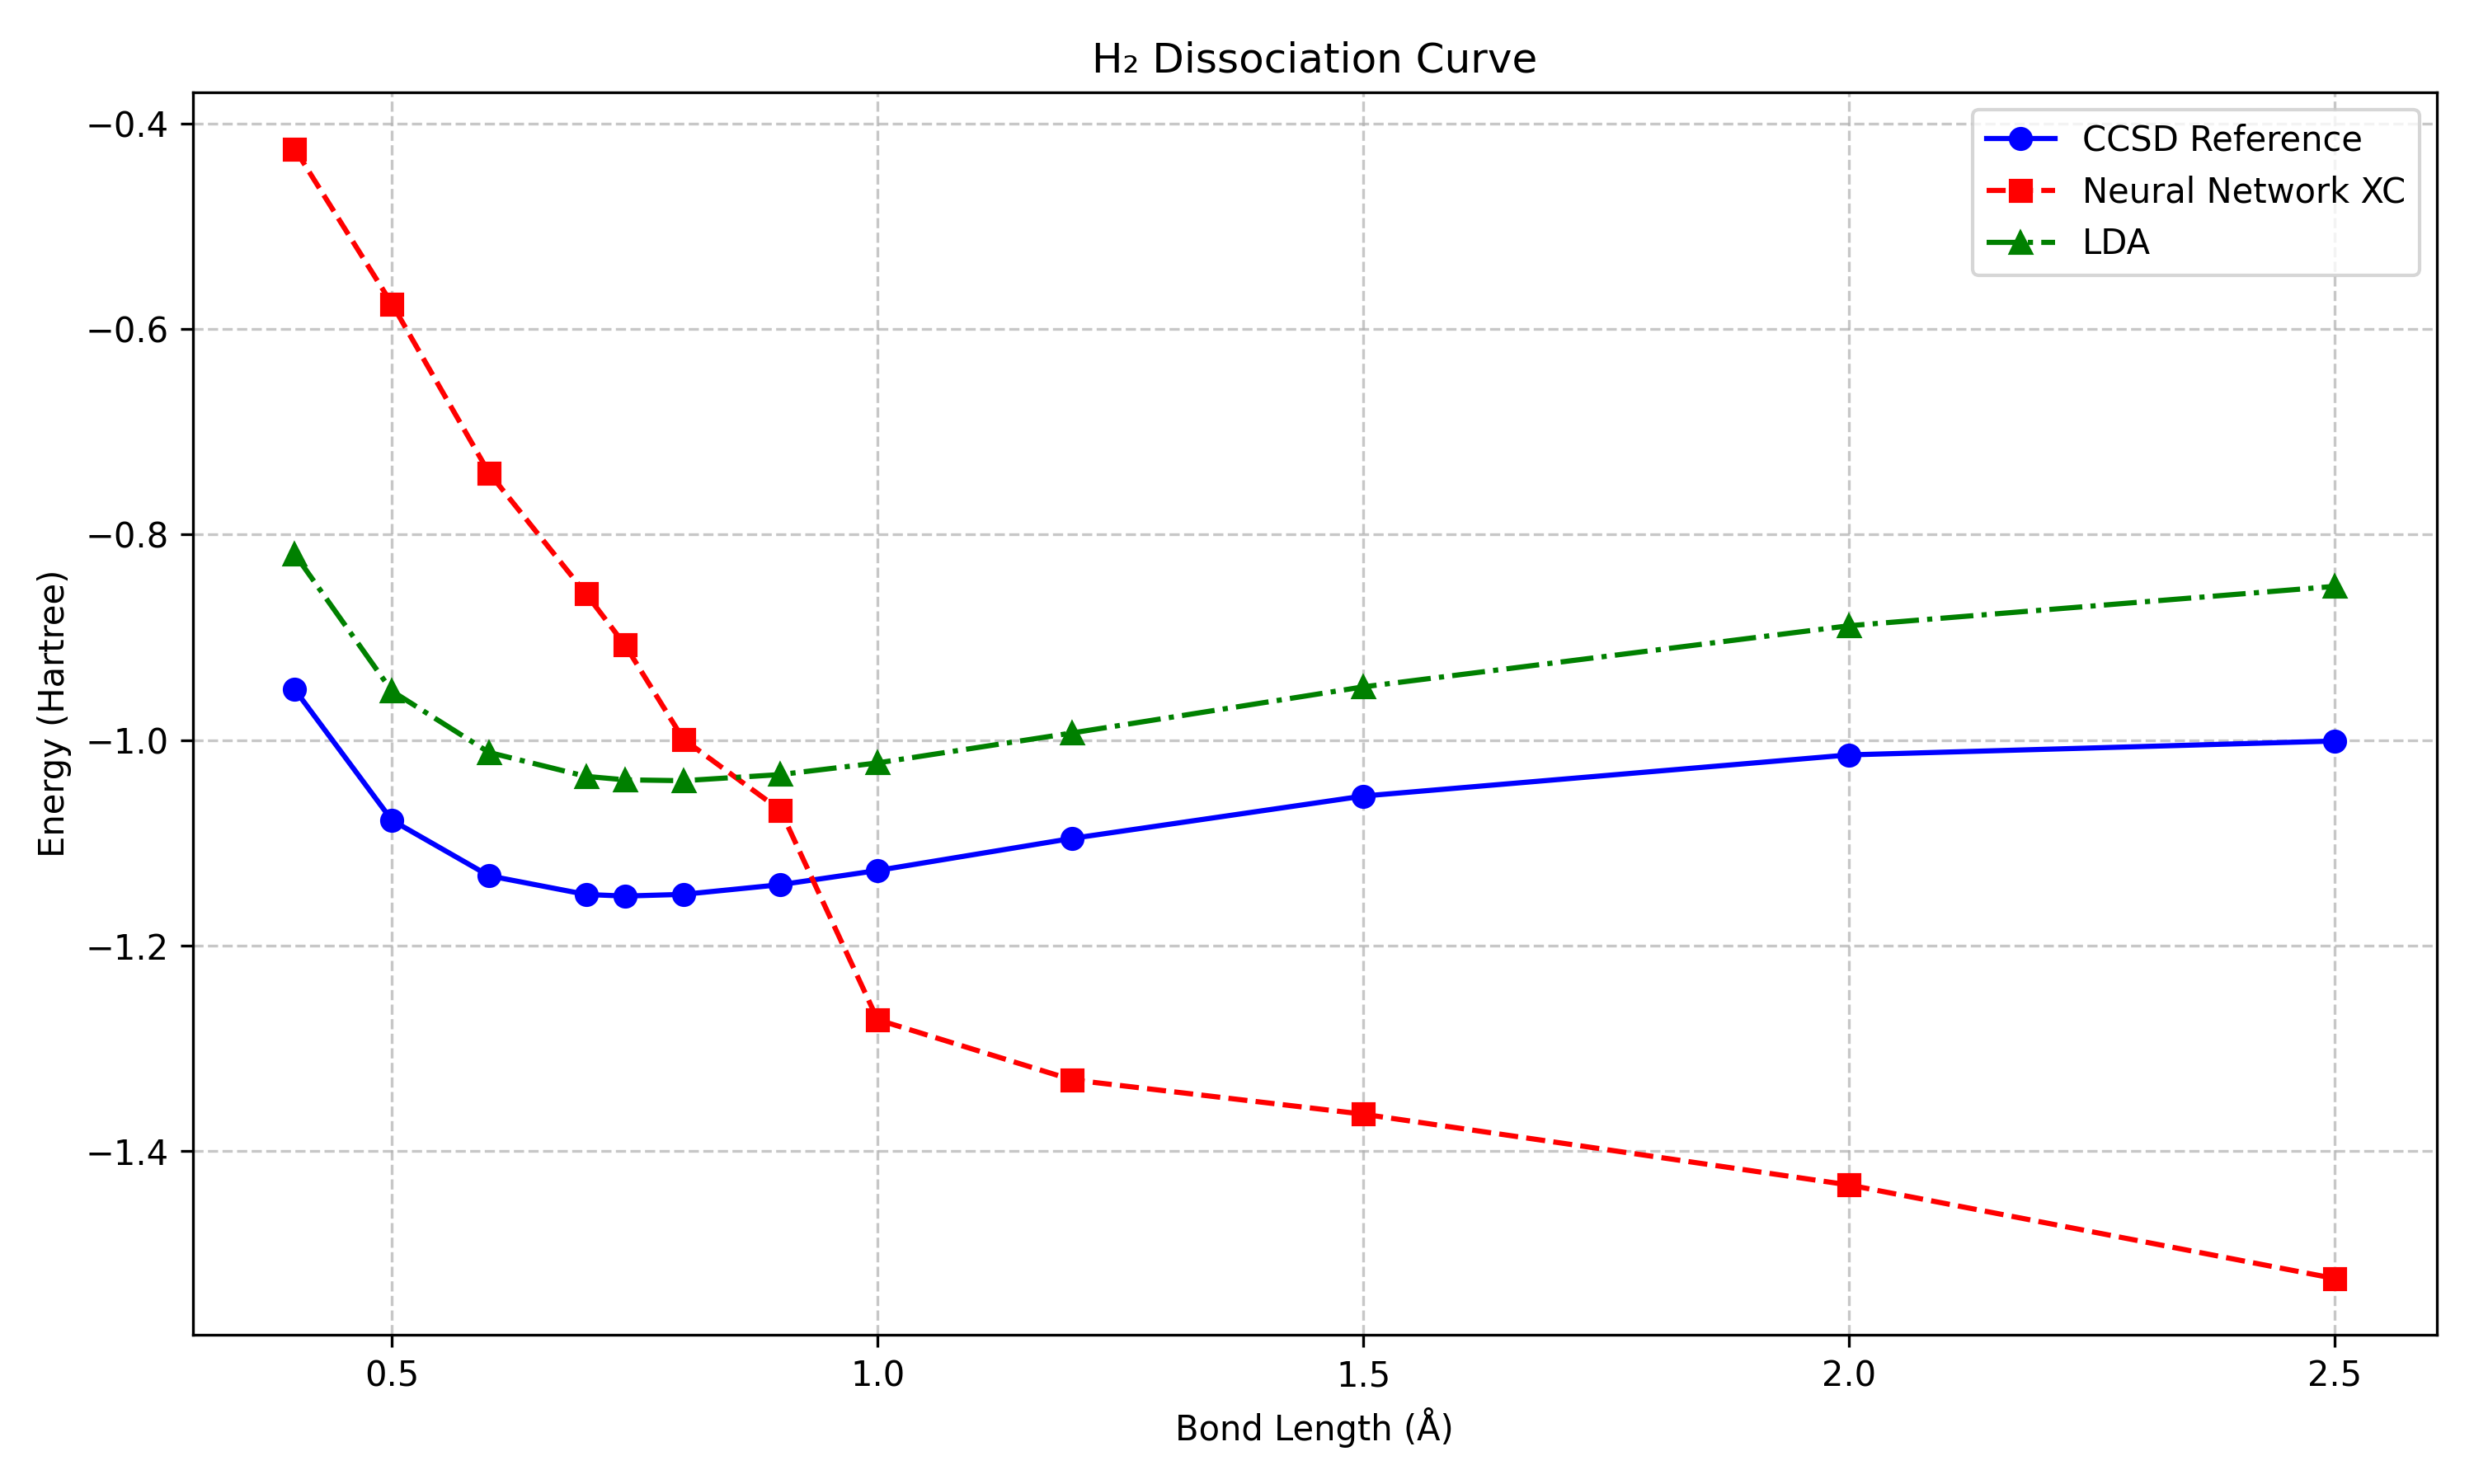

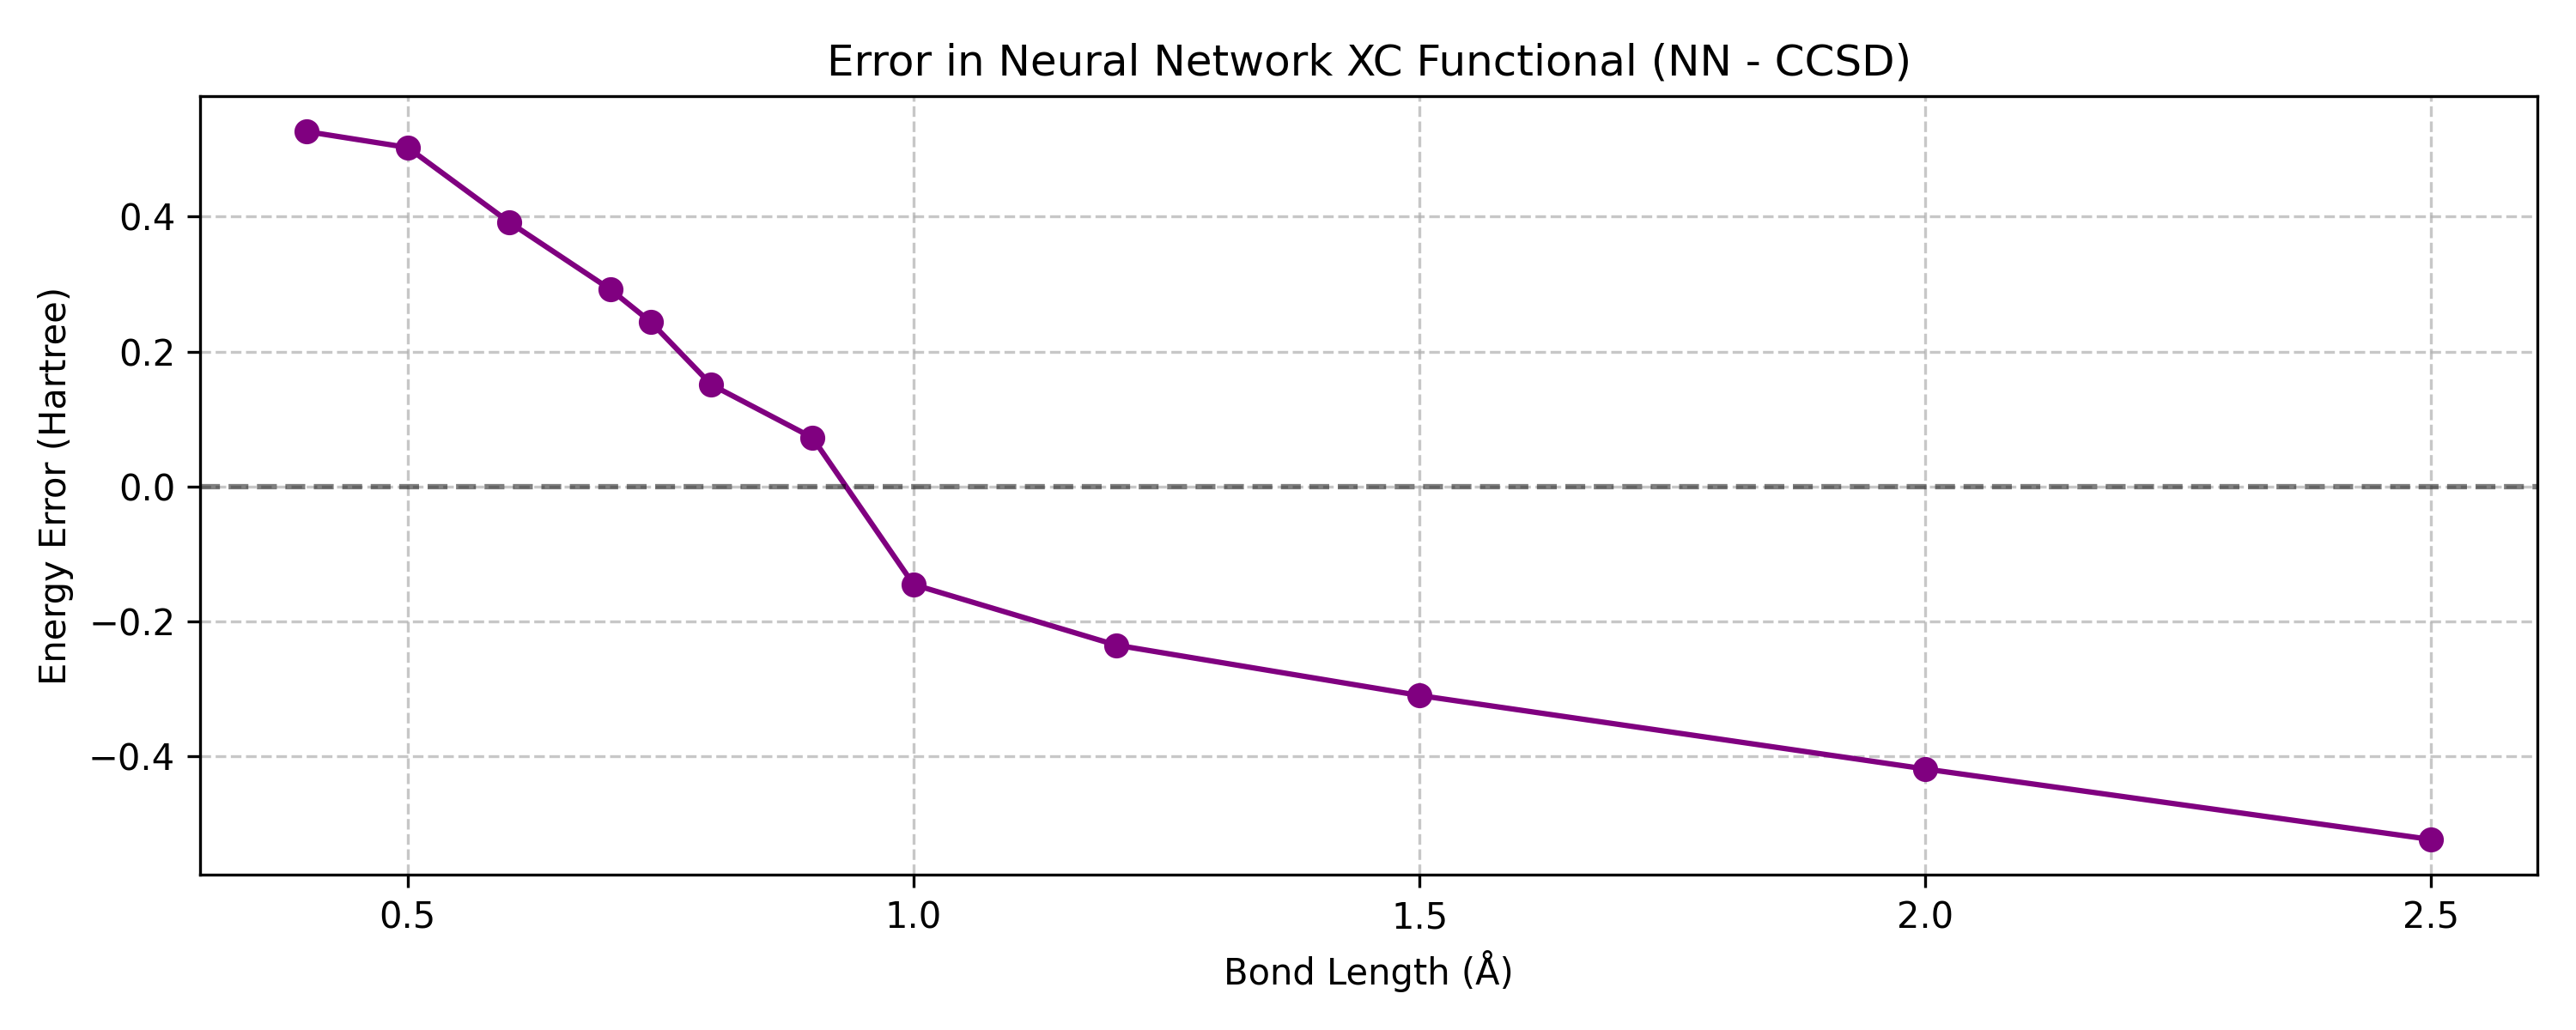

In [12]:
from pathlib import Path
from IPython.display import Image, display

checkpoint_path = Path(trainer.results_dir) / "trained_model_final.npy"

bond_lengths = [0.4, 0.5, 0.6, 0.7, 0.74, 0.8, 0.9, 1.0, 1.2, 1.5, 2.0, 2.5]

trainer.evaluate(
    checkpoint_path=checkpoint_path,
    bond_lengths=bond_lengths,
    use_lda=True,
    output_path=trainer.results_dir,
)

display(Image(filename=str(Path(trainer.results_dir) / "h2_dissociation_comparison.png")))
display(Image(filename=str(Path(trainer.results_dir) / "h2_dissociation_error.png")))

# Summary
- This notebook demonstrates training a neural network for Kohn-Sham DFT calculations
- We set up an H2 molecule configuration with different bond lengths for training and validation
- We use a GlobalMLP network architecture with 1192 (1240) grid points
- The network is trained using the TDKSDFTTrainer
- Training results (parameters, losses) are saved to the specified results directory
- The model learns to approximate the exchange-correlation functional for the H2 molecule system
- The notebook shows how to initialize, train, and evaluate the model performance
